In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/delaney.csv')

In [9]:
df.head()

,Compound ID,measured log(solubility:mol/L),ESOL predicted log(solubility:mol/L),SMILES
0,"1,1,1,2-Tetrachloroethane",-2.18,-2.794,ClCC(Cl)(Cl)Cl
1,"1,1,1-Trichloroethane",-2.00,-2.232,CC(Cl)(Cl)Cl
2,"1,1,2,2-Tetrachloroethane",-1.74,-2.549,ClC(Cl)C(Cl)Cl
3,"1,1,2-Trichloroethane",-1.48,-1.961,ClCC(Cl)Cl
4,"1,1,2-Trichlorotrifluoroethane",-3.04,-3.077,FC(F)(Cl)C(F)(Cl)Cl


In [4]:
df.shape

(1144, 4)

In [5]:
df.columns

Index(['Compound ID', 'measured log(solubility:mol/L)',
       'ESOL predicted log(solubility:mol/L)', 'SMILES'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1144 entries, 0 to 1143
Data columns (total 4 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Compound ID                           1144 non-null   object 
 1   measured log(solubility:mol/L)        1144 non-null   float64
 2   ESOL predicted log(solubility:mol/L)  1144 non-null   float64
 3   SMILES                                1144 non-null   object 
dtypes: float64(2), object(2)
memory usage: 35.9+ KB


In [7]:
df. describe( )

,measured log(solubility:mol/L),ESOL predicted log(solubility:mol/L)
count,1144.000000,1144.000000
mean,-3.057997,-2.994776
std,2.096502,1.686520
min,-11.600000,-9.702000
25%,-4.332250,-3.962250
50%,-2.870500,-2.889000
75%,-1.600000,-1.846750
max,1.580000,1.091000


In [11]:
print( "missing values ")
print ( df. isnull( ).sum( ))

missing values 
Compound ID                             0
measured log(solubility:mol/L)          0
ESOL predicted log(solubility:mol/L)    0
SMILES                                  0
dtype: int64


In [6]:
df.duplicated().sum()

np.int64(0)

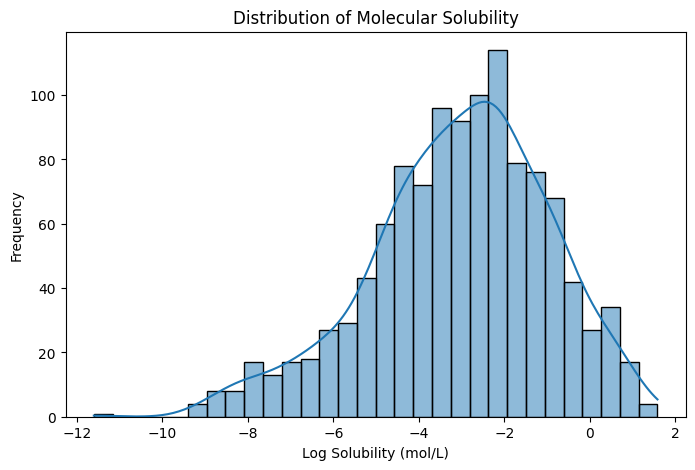

In [8]:
plt.figure(figsize=(8, 5))

sns.histplot(df['measured log(solubility:mol/L)'], bins=30, kde=True)

plt.title('Distribution of Molecular Solubility')
plt.xlabel('Log Solubility (mol/L)')
plt.ylabel('Frequency')

plt.show()

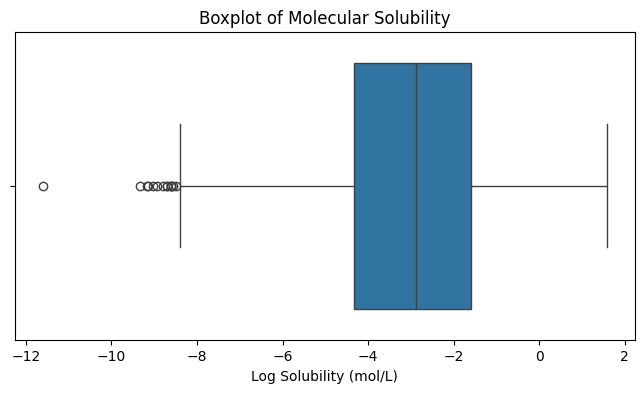

In [9]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df['measured log(solubility:mol/L)'])

plt.title('Boxplot of Molecular Solubility')
plt.xlabel('Log Solubility (mol/L)')

plt.show()

In [17]:
Q1 = df['measured log(solubility:mol/L)'].quantile(0.25)
Q3 = df['measured log(solubility:mol/L)'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
outliers = df[df['measured log(solubility:mol/L)'] < lower_bound]
print(outliers)

                      Compound ID  measured log(solubility:mol/L)  \
116  2,2',3,3',4,4',5,5',6,6'-PCB                         -11.600   
117       2,2',3,3',4,4',5,5'-PCB                          -9.160   
119       2,2',3,3',5,5',6,6'-PCB                          -9.150   
120             2,2',3,3',5,6-PCB                          -8.600   
123           2,2',3,4,5,5',6-PCB                          -8.940   
130            2,2',4,4',5,5'-PCB                          -8.560   
131            2,2',4,4',6,6'-PCB                          -8.710   
421                Benzo(a)pyrene                          -8.699   
426          Benzo(k)fluoranthene                          -8.490   
427            Benzo[ghi]perylene                          -9.018   
519                      Coronene                          -9.332   
671                    Etofenprox                          -8.600   
858                    Napthacene                          -8.600   
939                      Perylene 

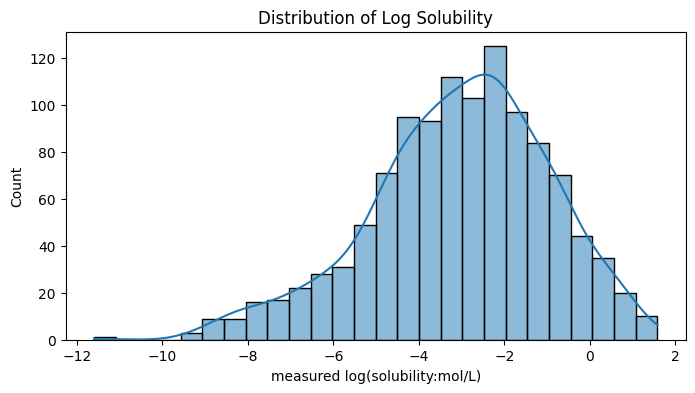

In [18]:
plt.figure(figsize=(8, 4))
sns.histplot(df['measured log(solubility:mol/L)'], kde=True)
plt.title('Distribution of Log Solubility')
plt.show()

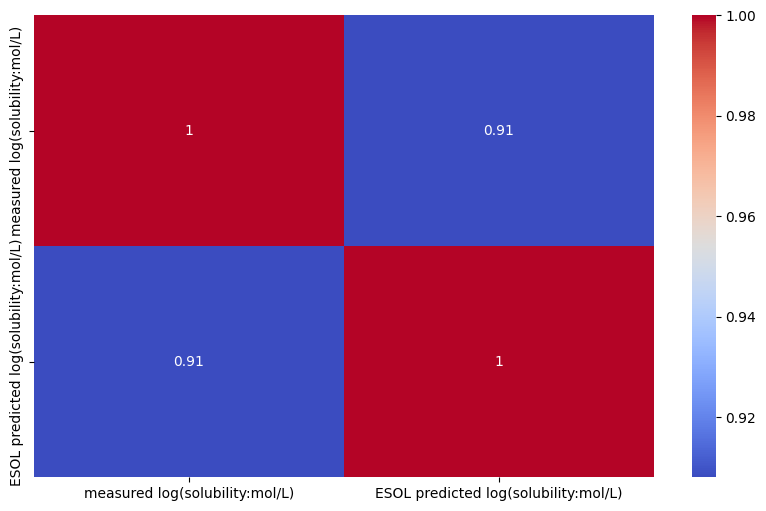

In [19]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [20]:
X = df.drop(columns=['measured log(solubility:mol/L)'])
y = df['measured log(solubility:mol/L)']

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# 1. دالة لاستخراج الميزات الكيميائية الرقمية من صيغة SMILES (Molecular Descriptors)
def generate_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return [
        Descriptors.MolLogP(mol),          # معامل التوزيع (LogP)
        Descriptors.MolWt(mol),            # الوزن الجزئي (Molecular Weight)
        Descriptors.NumRotatableBonds(mol),# عدد الروابط القابلة للدوران
        Descriptors.TPSA(mol)              # المساحة السطحية القطبية
    ]

# 2. تطبيق الـ Encoding على عمود الـ SMILES
descriptors_list = []
for smiles in df['SMILES']:
    descriptors_list.append(generate_descriptors(smiles))

# تحويل الميزات إلى DataFrame
feature_names = ['MolLogP', 'MolWt', 'NumRotatableBonds', 'TPSA']
X = pd.DataFrame(descriptors_list, columns=feature_names)

# 3. تحديد الـ Target وتحضير البيانات
y = df['measured log(solubility:mol/L)']

# حذف أي صفوف بها مشاكل في التحويل
valid_idx = X.dropna().index
X = X.loc[valid_idx]
y = y.loc[valid_idx]

print("شكل مصفوفة الميزات (X) بعد الـ Encoding:")
print(X.head())

# 4. تقسيم البيانات وتدريب النموذج
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# 5. التقييم
y_pred = model.predict(X_test)

print(f"\nR2 Score: {r2_score(y_test, y_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")

شكل مصفوفة الميزات (X) بعد الـ Encoding:
   MolLogP    MolWt  NumRotatableBonds  TPSA
0   2.5954  167.850                  0   0.0
1   2.3765  133.405                  0   0.0
2   2.5938  167.850                  1   0.0
3   2.0289  133.405                  1   0.0
4   2.9189  187.375                  1   0.0

R2 Score: 0.896
RMSE: 0.672


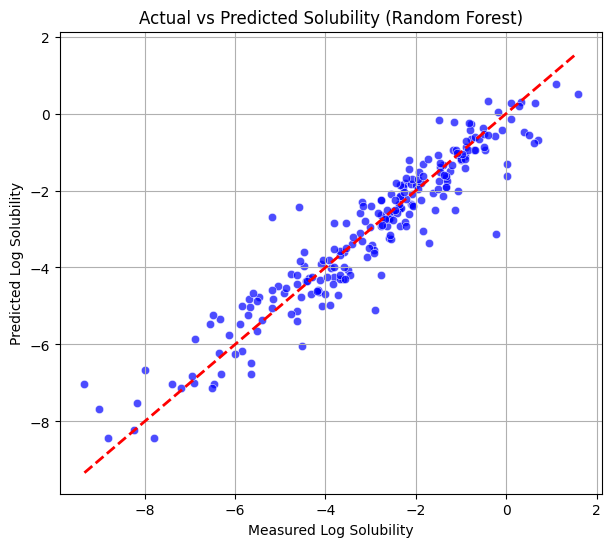

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # خط التطابق المثالي
plt.xlabel('Measured Log Solubility')
plt.ylabel('Predicted Log Solubility')
plt.title('Actual vs Predicted Solubility (Random Forest)')
plt.grid(True)
plt.show()

/tmp/ipykernel_3242/2695797458.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


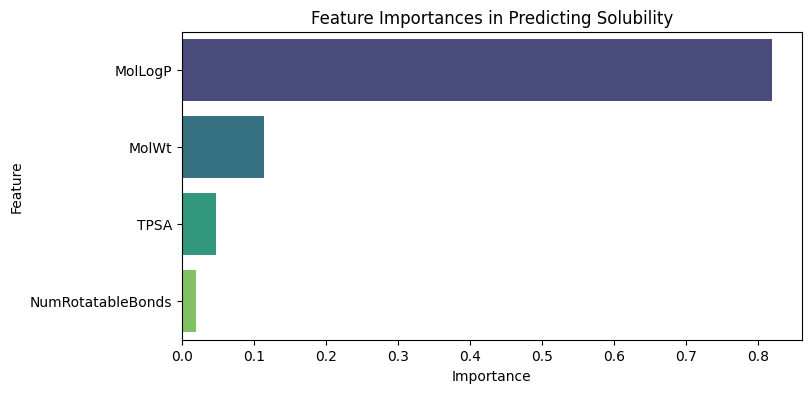

In [29]:
import pandas as pd

importances = model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Feature Importances in Predicting Solubility')
plt.show()

<Axes: xlabel='Importance', ylabel='Feature'>

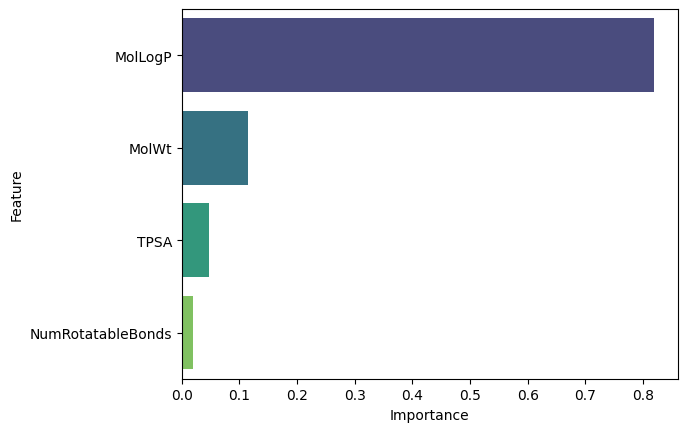

In [30]:
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, hue='Feature', palette='viridis', legend=False)

In [31]:
import joblib

# 1. حفظ النموذج
joblib.dump(model, 'solubility_model.pkl')
print("تم حفظ النموذج بنجاح!")

# 2. تجربة التنبؤ بمركب جديد تماماً باستخدام الـ SMILES
def predict_new_smiles(smiles):
    # تحميل النموذج
    loaded_model = joblib.load('solubility_model.pkl')

    # استخراج الخصائص
    descriptors = generate_descriptors(smiles)
    if descriptors is None:
        return "صيغة SMILES غير صحيحة"

    # التنبؤ
    features_df = pd.DataFrame([descriptors], columns=['MolLogP', 'MolWt', 'NumRotatableBonds', 'TPSA'])
    pred = loaded_model.predict(features_df)
    return pred[0]

# تجربة على مركب الأسبيرين (Aspirin) كمثال:
aspirin_smiles = 'CC(=O)OC1=CC=CC=C1C(=O)O'
predicted_solubility = predict_new_smiles(aspirin_smiles)
print(f"الذوبانية المتوقعة للأسبيرين: {predicted_solubility:.3f}")

تم حفظ النموذج بنجاح!
الذوبانية المتوقعة للأسبيرين: -1.447


In [32]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib
from rdkit import Chem
from rdkit.Chem import Descriptors

# ضبط إعدادات الصفحة
st.set_page_config(page_title="Molecular Solubility Predictor", layout="wide")

st.title("🧪 تنبؤ الذوبانية الجزيئية (Molecular Solubility Prediction)")
st.write("تطبيق مخصص لتوقع ذوبانية المركبات الكيميائية باستخدام نماذج التعلم الآلي و RDkit")

# دالة استخراج الخصائص الكيميائية
def generate_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return [
        Descriptors.MolLogP(mol),
        Descriptors.MolWt(mol),
        Descriptors.NumRotatableBonds(mol),
        Descriptors.TPSA(mol)
    ]

# تحميل النموذج المحفوظ
@st.cache_resource
def load_model():
    return joblib.load('solubility_model.pkl')

try:
    model = load_model()
except FileNotFoundError:
    st.error("لم يتم العثور على ملف النموذج `solubility_model.pkl`. يرجى حفظه بنفس مجلد المشروع.")
    st.stop()

# تقسيم الشاشة إلى تبويبين
tab1, tab2 = st.tabs(["🔍 تجربة مركب منفرد", "📁 معالجة ملف بيانات كبير (Batch Prediction)"])

# --- التبويب الأول: مركب واحد ---
with tab1:
    st.subheader("توقع ذوبانية مركب بواسطة SMILES")
    single_smiles = st.text_input("أدخل كود SMILES للمركب:", "CC(=O)OC1=CC=CC=C1C(=O)O")

    if st.button("توقع الذوبانية"):
        desc = generate_descriptors(single_smiles)
        if desc is None:
            st.error("صيغة SMILES غير صحيحة، يرجى التأكد منها.")
        else:
            df_features = pd.DataFrame([desc], columns=['MolLogP', 'MolWt', 'NumRotatableBonds', 'TPSA'])
            prediction = model.predict(df_features)[0]
            st.success(f"الذوبانية المتوقعة (Log Solubility): **{prediction:.3f}**")
            st.dataframe(df_features)

# --- التبويب الثاني: رفع ملف كبير ---
with tab2:
    st.subheader("رفع ملف يحتوي على بيانات كثيرة")
    uploaded_file = st.file_uploader("قم برفع ملف CSV يحتوي على عمود باسم SMILES:", type=['csv'])

    if uploaded_file is not None:
        input_df = pd.read_csv(uploaded_file)
        st.write(f"تم تحميل الملف بنجاح! عدد الصفوف: **{len(input_df)}**")

        if 'SMILES' in input_df.columns:
            if st.button("بدء التنبؤ للبيانات كاملة"):
                with st.spinner("جاري معالجة المركبات واستخراج الميزات..."):
                    results = []
                    valid_mask = []

                    for smiles in input_df['SMILES']:
                        desc = generate_descriptors(str(smiles))
                        if desc is not None:
                            results.append(desc)
                            valid_mask.append(True)
                        else:
                            results.append([np.nan]*4)
                            valid_mask.append(False)

                    # إنشاء dataframe للميزات والتنبؤ
                    features_df = pd.DataFrame(results, columns=['MolLogP', 'MolWt', 'NumRotatableBonds', 'TPSA'])

                    # التنبؤ للقيم الصحيحة فقط
                    preds = []
                    for idx, row in features_df.iterrows():
                        if valid_mask[idx]:
                            preds.append(model.predict([row.values])[0])
                        else:
                            preds.append(np.nan)

                    input_df['Predicted_Log_Solubility'] = preds

                    st.success("تم التنبؤ لجميع البيانات بنجاح!")
                    st.dataframe(input_df.head(20)) # عرض أول 20 صف

                    # زر لتنزيل الملف بعد التعديل
                    csv = input_df.to_csv(index=False).encode('utf-8')
                    st.download_button(
                        label="⬇️ تنزيل النتائج الكاملة (CSV)",
                        data=csv,
                        file_name='solubility_predictions.csv',
                        mime='text/csv'
                    )
        else:
            st.error("تأكد أن الملف يحتوي على عمود يسمى 'SMILES'")

ModuleNotFoundError: No module named 'streamlit'